# pathmap使用


{'topic': '猫咪', 'poem': '## 《猫咪》\n\n你踱向我的时候\n整个黄昏都松了口气\n影子是液态的\n慢慢填满砖缝里正枯萎的时光\n\n目光的弧度刚好\n绕过窗外雪地尽头那棵老橡树\n跃上窗台\n旧月历哗啦啦翻过三页\n四月落在你脚边\n\n过道里你突然静止\n听清空气里看不见的乐章\n随即轻盈地追逐\n窗帘下忽明忽暗的光粒\n墙壁长出柔软的壳\n\n你用短暂的一生与我共处\n余下的时光用来缱绻', 'ci_poem': '**《猫咪的比喻》**\n\n猫咪是——\n午后三点的绒线团\n沿着光柱缓缓滚落\n沙发是个温暖的岛屿\n它们用尾巴测量时间\n\n猫咪是——\n液态的雕塑家\n从窗台流到地板\n在纸箱里凝固成\n一座毛茸茸的城堡\n只有呼噜声证明\n它们还活在地球上\n\n猫咪是——\n会走路的诗\n用肉垫押韵\n用胡须标点\n当它们眯起眼睛\n整片天空都变得柔软\n\n猫咪是——\n不服管的哲学家\n拒绝所有命令句\n把“过来”听成“等等”\n把“下来”听成“或许”\n它们教会我们\n如何优雅地\n不听话\n\n猫咪是——\n夜晚的微型老虎\n在窗帘后埋伏\n把拖鞋当作猎物\n然后突然发现\n自己才是被亲亲\n打败的那一个\n\n猫咪是——\n永远的家\n是回家的理由\n是那个在门口等你的人\n尽管它们从来不说\n只是用额头\n轻轻顶进你的掌心', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '小明去朋友家玩，看到朋友家的猫正蹲在路由器上，一动不动。\n\n小明好奇地问：“你家猫干嘛呢？在修行吗？”\n\n朋友淡定地回答：“没有，它在上网。”\n\n小明：“上网？它连爪子都没动啊！”\n\n朋友：“你不懂，它用的是‘猫’的无线——喵喵喵（猫猫）Wi-Fi。”\n\n小明：“那它为什么蹲在路由器上？”\n\n朋友：“为了信号好，毕竟它自己是‘猫’，但Wi-Fi还是要蹭的。”\n\n小明：“……所以它现在是在？”\n\n朋友：“刷猫片。”', 'ci_poem': '关于“猫咪”的诗意小词，可以是一段随想，也可以成一首短诗。这里为你写了一个意境温柔的词：\n\n---\n\n**《猫榻》**\n\n那团毛茸茸的暖，\n是午后三点的云，\n是木地板上泄了一个小口的温柔。\n\n它把自己盘成问号

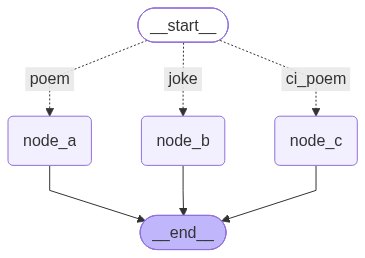

In [1]:
from typing import TypedDict, Literal, Sequence

from IPython.display import display
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END

load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str
    content_type: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke(f"请写一个关于{state["topic"]}的词").content
    return {
        "ci_poem": ci_poem
    }


# 定义路由
# 此时返回为内容，无法进行路由自动映射，需要通过pathmap
# 返回多个，需要用到Sequence
def route(state: OverAllState) -> Sequence[Literal["poem", "joke", "ci_poem"]]:
    if "诗" in state["content_type"]:
        return ["poem", "ci_poem"]
    else:
        return ["joke", "ci_poem"]


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(node_c)
# path_map key是路由的返回值，value：对应的真实节点名称
builder.add_conditional_edges(START, route, path_map={
    "poem": "node_a",
    "joke": "node_b",
    "ci_poem": "node_c",
})
builder.add_edge("node_b", END)
builder.add_edge("node_a", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪", "content_type": "笑话"})
print(joke_res)

display(graph)